In [113]:
import numpy as np
import matplotlib.pyplot as plt

## Math
from scipy import signal
from scipy.fft import ifft, rfft, rfftfreq

## FaIR
from fair import FAIR
from fair.io import read_properties
from fair.interface import initialise, fill
import run_fair

## Helpers
import utils_TF

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Generate all responses

In [212]:
start, stop = 1750, 2500
years = np.arange(start, stop)
n_steps = len(years)
dt = 1
freq_s = 1
nperseg = 250
response_dict = run_fair.generate_responses(start, stop, n_steps, years, dt, freq_s, nperseg)

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

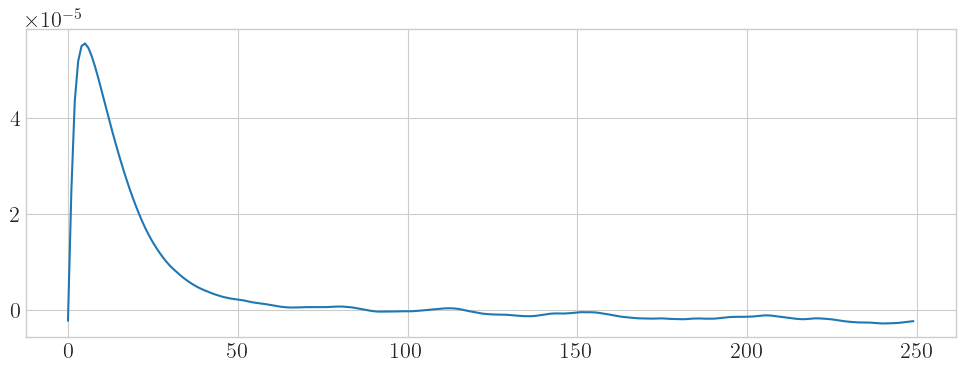

In [285]:
#plt.plot(response_dict['CO2']['h_est_CT'])
plt.plot(response_dict['CH4']['h_est_ET'])
#plt.plot(response_dict['CH4']['h_est_CT'])
#plt.plot(response_dict['N2O']['h_est_CT'])

#### 1b. Emission to Concentration

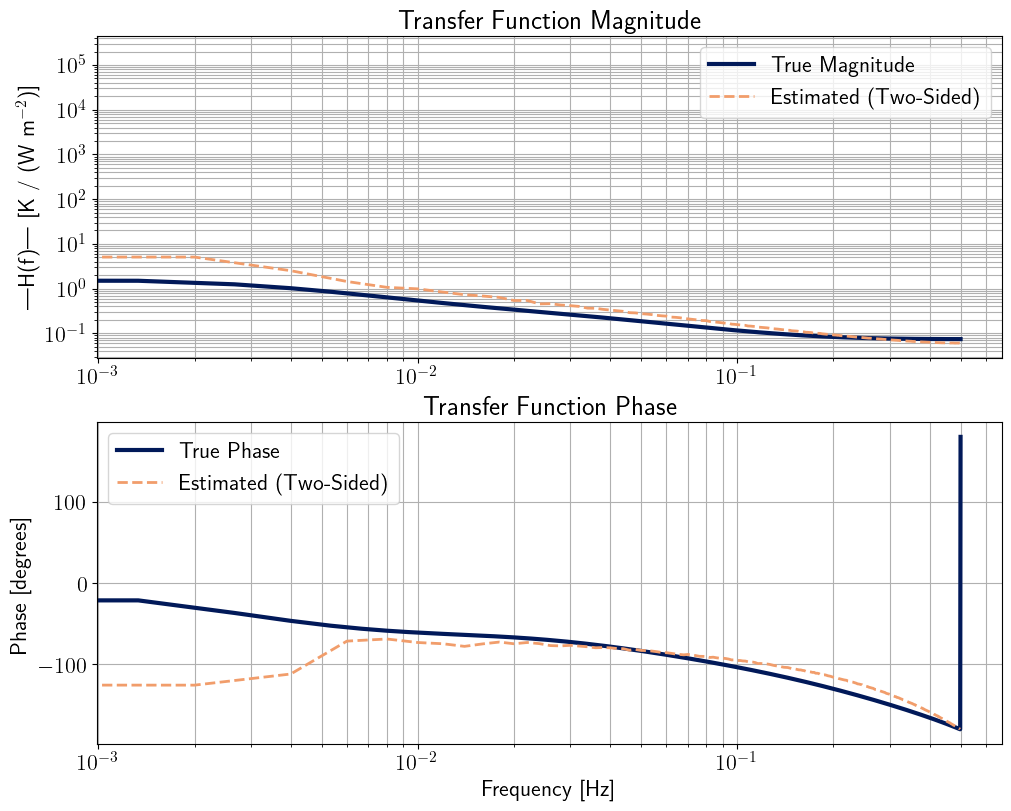

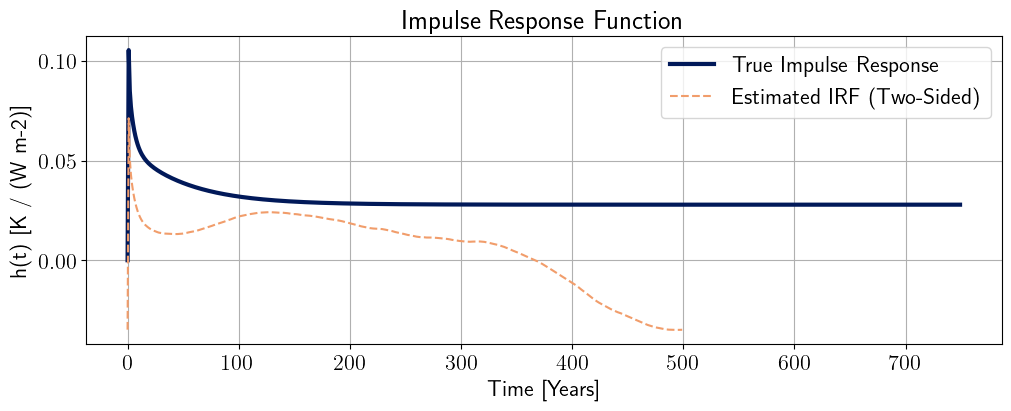

In [184]:
freq_s = 1
nperseg = 500
H_est_CO2_EC_mean, h_est_CO2_EC_mean, freq_CO2_EC = utils_TF.identify_system(emis_CO2_mean, conc_CO2_mean, freq_s, nperseg)

utils_TF.plot_freq(H_est_CO2_EC_mean, freq_CO2_EC, plot_true=True, H_true=H_true_CO2_EC_mean, f_true=freq_true_CO2)
utils_TF.plot_time(h_est_CO2_EC_mean, plot_true=True, h_true=h_true_CO2_EC_mean - h_true_CO2_EC_mean[0])

#### 1c. Emissions to Forcing

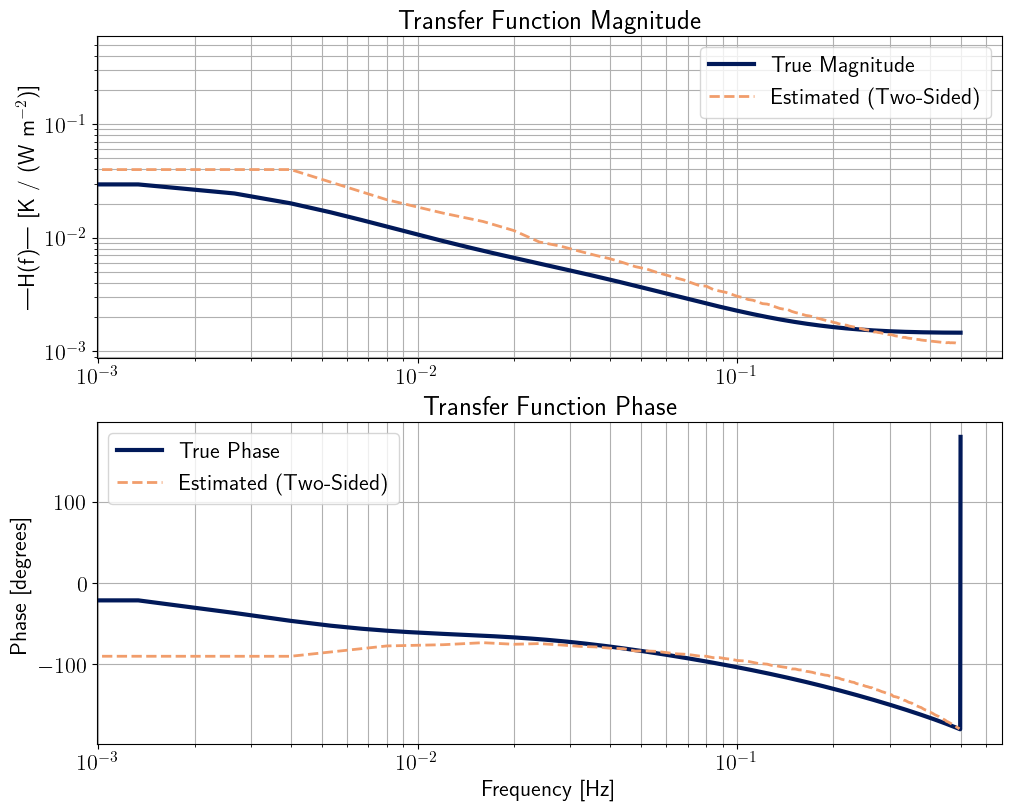

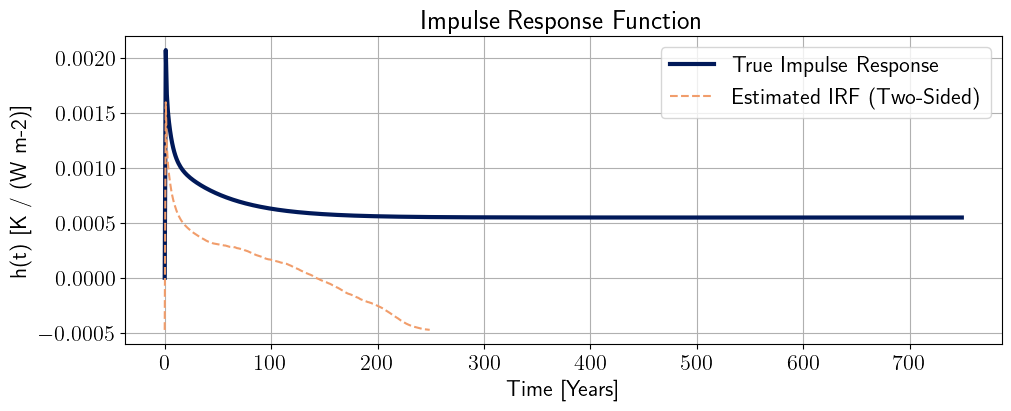

In [185]:
freq_s = 1
nperseg = 250
H_est_CO2_EF_mean, h_est_CO2_EF_mean, freq_CO2_EF = utils_TF.identify_system(emis_CO2_mean, forc_CO2_mean, freq_s, nperseg)

utils_TF.plot_freq(H_est_CO2_EF_mean, freq_CO2_EF, plot_true=True, H_true=H_true_CO2_EF_mean, f_true=freq_true_CO2)
utils_TF.plot_time(h_est_CO2_EF_mean, plot_true=True, h_true=h_true_CO2_EF_mean)

#### 1d. Emissions to Temperature

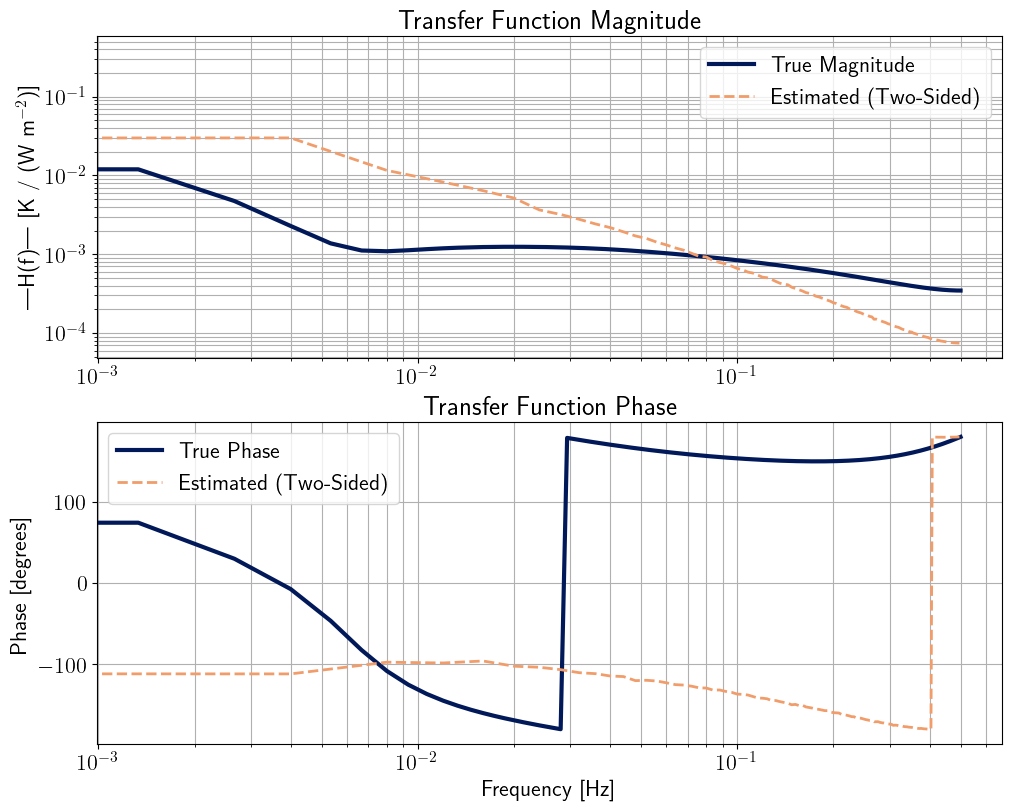

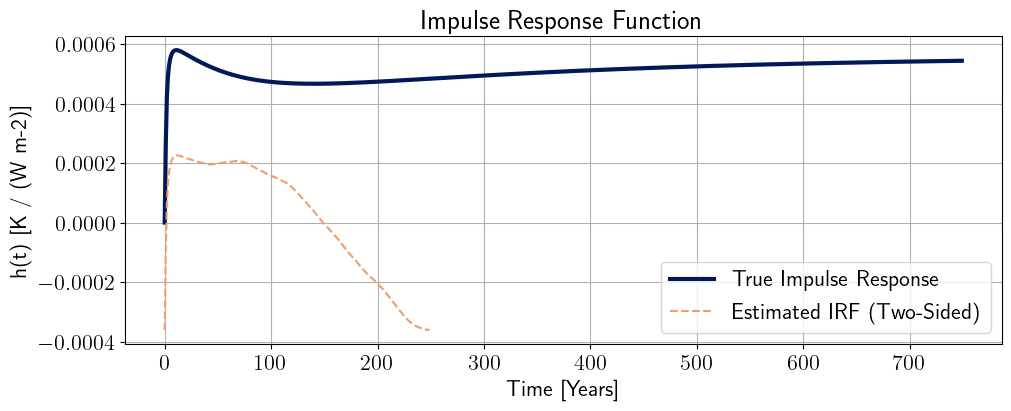

In [183]:
freq_s = 1
nperseg = 250
H_est_CO2_ET_mean, h_est_CO2_ET_mean, freq_CO2_ET = utils_TF.identify_system(emis_CO2_mean, T_CO2_mean, freq_s, nperseg)

utils_TF.plot_freq(H_est_CO2_ET_mean, freq_CO2_ET, plot_true=True, H_true=H_true_CO2_ET_mean, f_true=freq_true_CO2)
utils_TF.plot_time(h_est_CO2_ET_mean, plot_true=True, h_true=h_true_CO2_ET_mean)

#### 1e. Concentration to Forcing

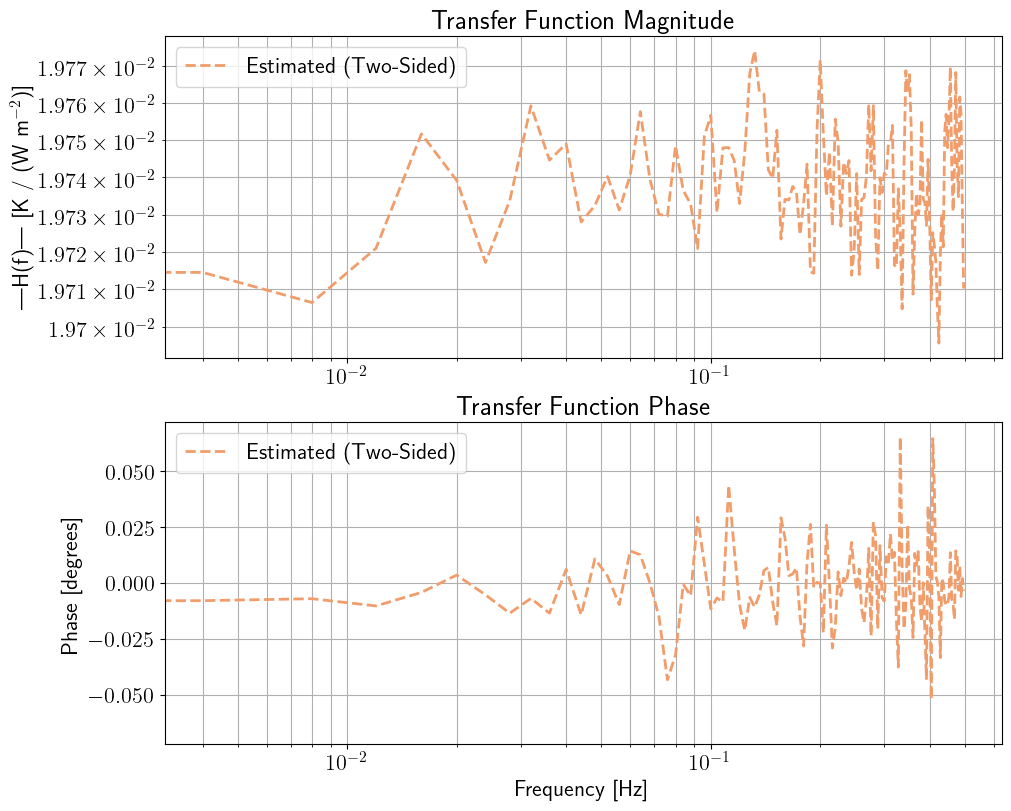

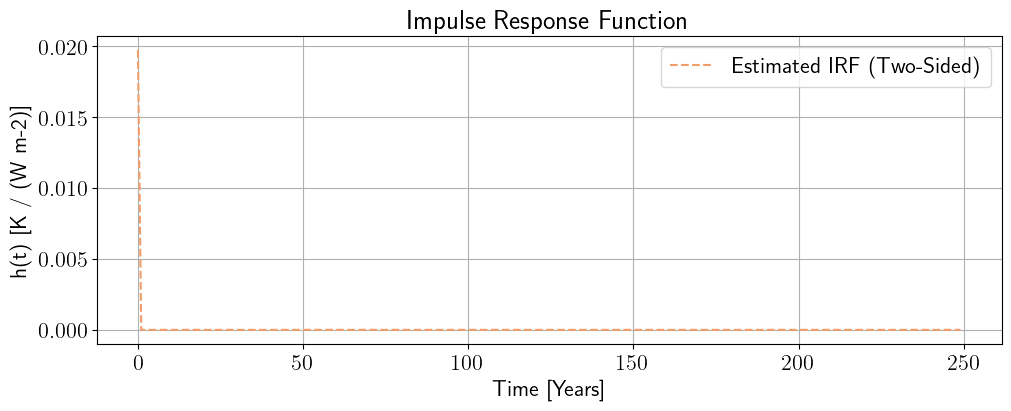

In [195]:
freq_s = 1
nperseg = 250
H_est_CO2_CF_mean, h_est_CO2_CF_mean, freq_CO2_CF = utils_TF.identify_system(conc_CO2_mean, forc_CO2_mean, freq_s, nperseg)

utils_TF.plot_freq(H_est_CO2_CF_mean, freq_CO2_CF)#, plot_true=True, H_true=H_true_CO2_CF_mean, f_true=freq_true_CO2)
utils_TF.plot_time(h_est_CO2_CF_mean)#, plot_true=True, h_true=h_true_CO2_CF_mean)

#### 1f. Concentration to Temperature

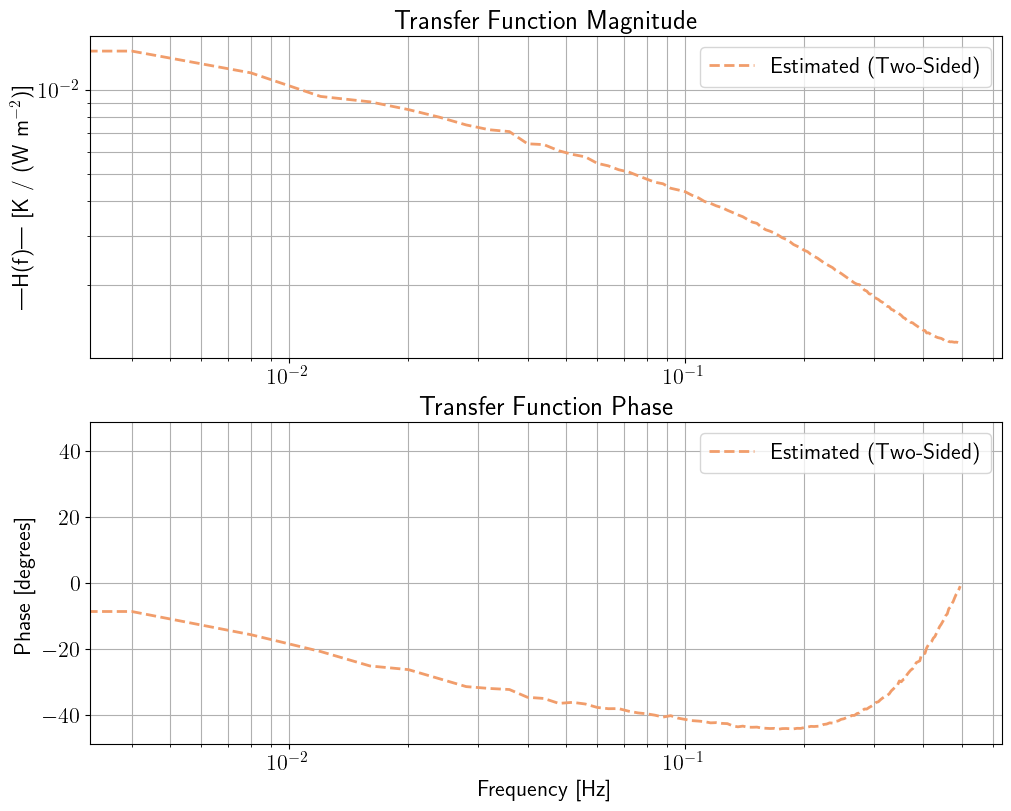

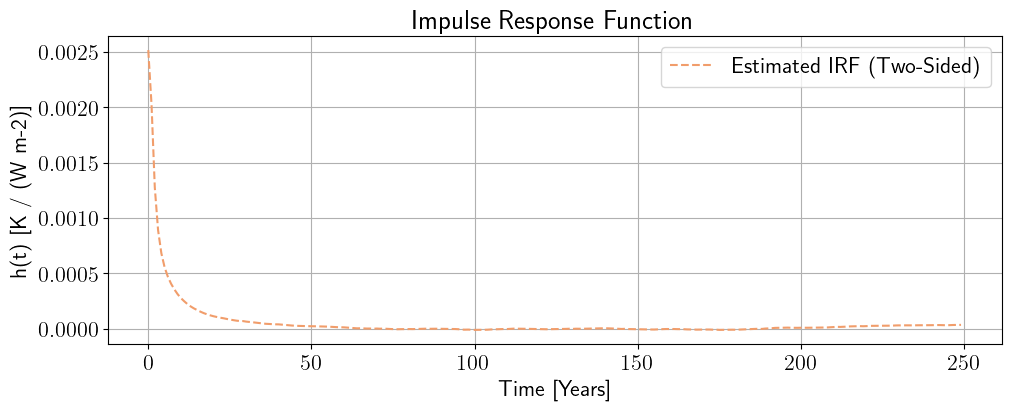

In [194]:
freq_s = 1
nperseg = 250
H_est_CO2_CT_mean, h_est_CO2_CT_mean, freq_CO2_CT = utils_TF.identify_system(conc_CO2_mean, T_CO2_mean, freq_s, nperseg)

utils_TF.plot_freq(H_est_CO2_CT_mean, freq_CO2_CT)#, plot_true=True, H_true=H_true_CO2_CT_mean, f_true=freq_true_CO2)
utils_TF.plot_time(h_est_CO2_CT_mean)#, plot_true=True, h_true=h_true_CO2_CT_mean)

#### 1e. Forcing to Temperature

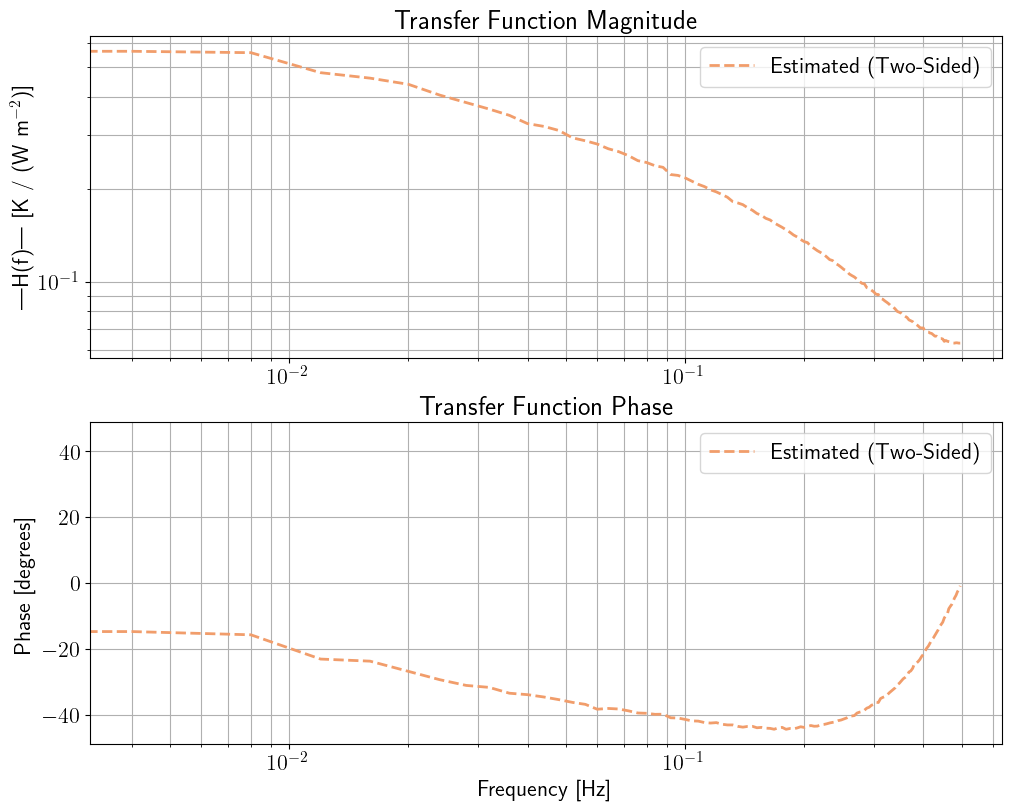

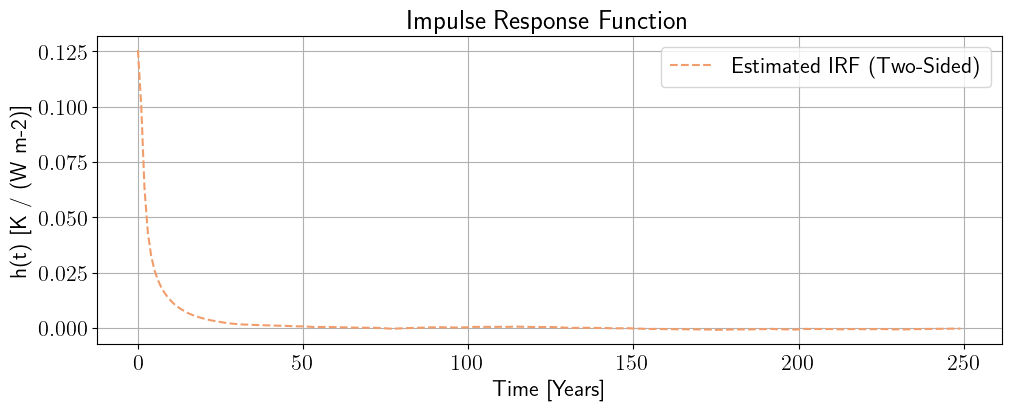

In [180]:
freq_s = 1
nperseg = 250
H_est_CO2_FT_mean, h_est_CO2_FT_mean, freq_CO2_FT = utils_TF.identify_system(forc_CO2_mean, T_CO2_mean, freq_s, nperseg)

utils_TF.plot_freq(H_est_CO2_FT_mean, freq_CO2_FT)#, plot_true=True)#, H_true=H_true_CO2_FT_mean, f_true=freq_true_CO2)
utils_TF.plot_time(h_est_CO2_FT_mean)#, plot_true=True)#, h_true=h_true_CO2_FT_mean)

#### 1a. Emissions to Concentrations

In [220]:
def inner_product(v, u):
  """
  Calculates the inner product (dot product) of two vectors.
  """
  return np.dot(v, u)

def project(v, u):
  """
  Calculates the projection of vector v onto vector u.
  proj_u(v) = (<v,u>/<u,u>) * u
  """
  # Avoid division by zero if u is the zero vector
  u_dot_u = inner_product(u, u)
  if u_dot_u == 0:
    return np.zeros_like(v)
  return (inner_product(v, u) / u_dot_u) * u

def generate_uncorrelated_signals(n, signal_length=1000):
  """
  Generates n uncorrelated white noise signals of a specified length.

  Args:
    n (int): The number of signals to generate.
    signal_length (int): The number of samples in each signal.

  Returns:
    tuple: A tuple containing:
      - v_signals (np.ndarray): The original correlated white noise signals.
      - e_signals (np.ndarray): The final uncorrelated (orthonormal) signals.
  """
  if n <= 0:
    raise ValueError("Number of signals (n) must be a positive integer.")
  if signal_length <= 0:
    raise ValueError("Signal length must be a positive integer.")

  # 1. Generate n white noise signals (v_n)
  # Each signal is a row in the matrix
  v_signals = np.random.randn(n, signal_length)

  u_signals = np.zeros_like(v_signals)
  e_signals = np.zeros_like(v_signals)

  # 2. Apply the Gram-Schmidt process to create uncorrelated signals (u_n)
  for i in range(n):
    v_i = v_signals[i]
    u_i = v_i
    # Subtract projections onto previous u signals
    for j in range(i):
      u_j = u_signals[j]
      u_i -= project(v_i, u_j)
    u_signals[i] = u_i

    # 3. Normalize the uncorrelated signals to get the final signals (e_n)
    # e_i = u_i / ||u_i||
    norm_u_i = np.linalg.norm(u_i)
    if norm_u_i > 1e-10: # Avoid division by zero for very small norms
        e_signals[i] = u_i / norm_u_i
    else:
        # If a vector is nearly zero, it means the original set was linearly dependent
        # We can leave it as a zero vector or handle as an error.
        e_signals[i] = np.zeros(signal_length)


  return v_signals, e_signals

def verify_and_plot(e_signals):
    """
    Verifies that the signals are uncorrelated and have a norm of 1, then plots them.
    """
    n_signals = e_signals.shape[0]

    # --- Verification ---
    print("--- Verification ---")
    # Check L2 norm (should be 1)
    print("\nVerifying L2 Norms (should be close to 1.0):")
    for i in range(n_signals):
        norm = np.linalg.norm(e_signals[i])
        print(f"  Norm of e_{i+1}: {norm:.6f}")

    # Check correlation (inner product of different signals should be 0)
    print("\nVerifying Correlation (dot products of e_i, e_j for i!=j should be close to 0.0):")
    # Only show the upper triangle of the correlation matrix for brevity
    for i in range(n_signals):
        for j in range(i + 1, n_signals):
            corr = inner_product(e_signals[i], e_signals[j])
            print(f"  <e_{i+1}, e_{j+1}>: {corr: .6f}")

    # --- Plotting ---
    time = np.arange(e_signals.shape[1])
    fig, axes = plt.subplots(n_signals, 1, figsize=(12, 2 * n_signals), sharex=True)
    fig.suptitle('Generated Uncorrelated White Noise Signals (e_n)', fontsize=16)

    # Handle case where n=1, axes is not an array
    if n_signals == 1:
        axes = [axes]

    for i in range(n_signals):
        axes[i].plot(time, e_signals[i], label=f'e_{i+1}')
        axes[i].set_ylabel(f'e_{i+1}')
        axes[i].grid(True, linestyle='--', alpha=0.6)
        axes[i].legend(loc='upper right')

    axes[-1].set_xlabel('Sample Number')
    plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust layout to make room for suptitle
    plt.show()

--- Verification ---

Verifying L2 Norms (should be close to 1.0):
  Norm of e_1: 1.000000
  Norm of e_2: 1.000000

Verifying Correlation (dot products of e_i, e_j for i!=j should be close to 0.0):
  <e_1, e_2>:  0.000000


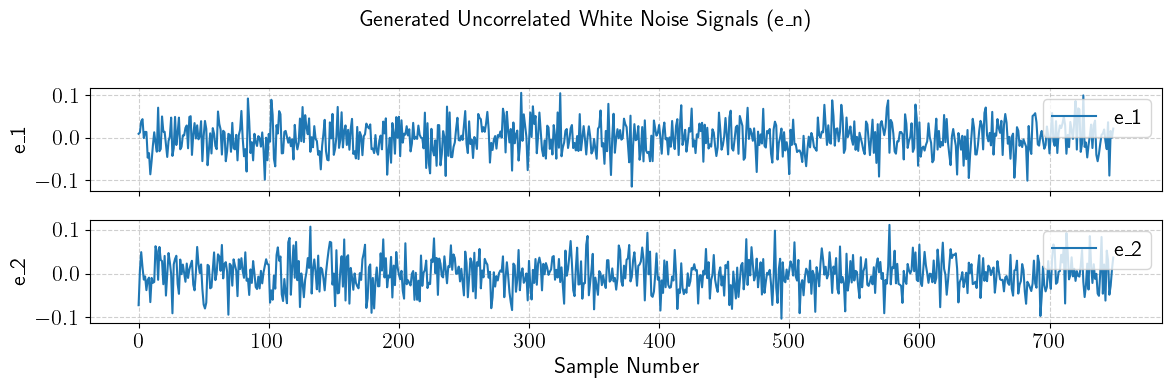

In [223]:
n = 2
signal_length = n_steps
v, e = generate_uncorrelated_signals(n, signal_length)
verify_and_plot(e)

In [279]:
start, stop = 1750, 2500
years = np.arange(start, stop)
n_steps = len(years)
dt = 1
freq_s = 1
nperseg = 250
fair = fair_pulse = run_fair.initialise_fair(start, stop)

#co2, ch4 = e[0], e[1]
ch4 = np.linspace(0, 1000, n_steps)
nan_force = np.linspace(0, 0, n_steps)

agents = ['CO2','CH4','N2O','Sulfur','BC']
emission_dict = {
  'CO2':nan_force,
  'CH4':ch4,
  'N2O':nan_force,
  'Sulfur':nan_force,
  'BC':nan_force
}

t, T_ens, T_mean, ECS = run_fair.run_multi_agent(fair, n_steps, years, agents, emission_dict)

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

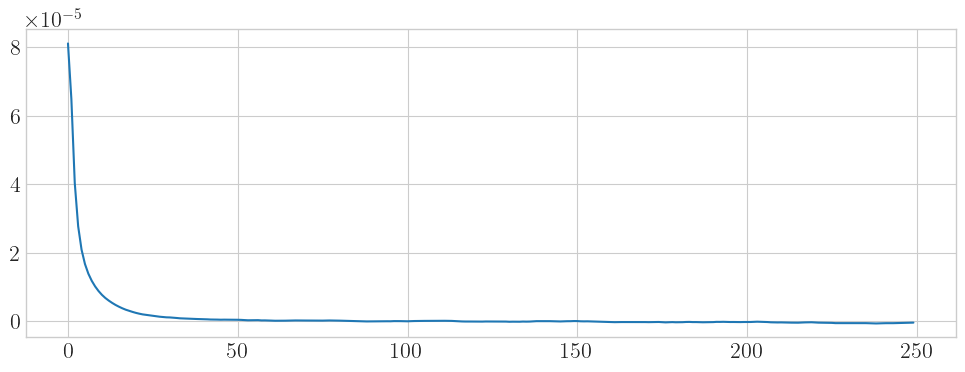

In [282]:
plt.plot(response_dict['CH4']['h_est_CT'])

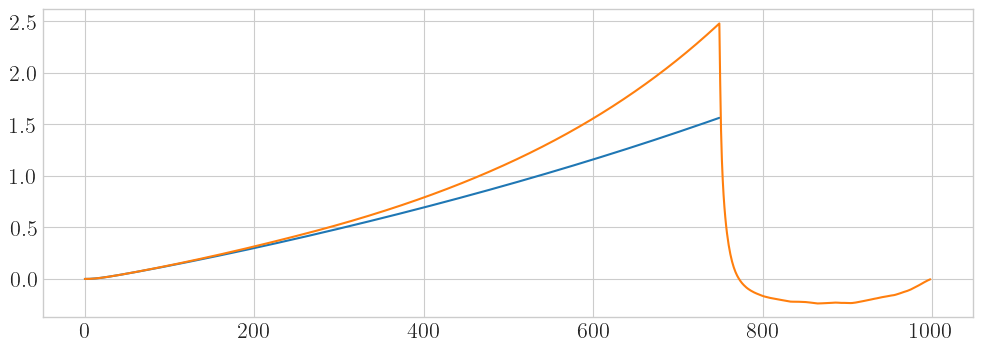

In [284]:
plt.plot(T_mean)
plt.plot(np.convolve(ch4_conc - 729.2,response_dict['CH4']['h_est_CT'], mode='full'))

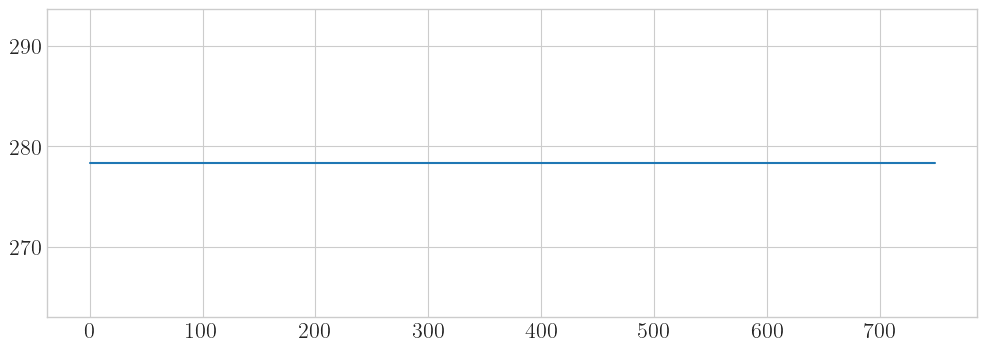

In [281]:
co2_conc = np.mean(fair.concentration.sel(timebounds=slice(min(years), max(years))).loc[dict(scenario='custom')].sel(specie='CO2').values, axis=1)
ch4_conc = np.mean(fair.concentration.sel(timebounds=slice(min(years), max(years))).loc[dict(scenario='custom')].sel(specie='CH4').values, axis=1)

plt.plot(co2_conc)
#plt.plot(np.mean(fair.forcing.sel(timebounds=slice(min(years), max(years))).loc[dict(scenario='custom')].sel(specie='CH4').values, axis=1))

In [257]:
magnitude_co2 = inner_product(T_mean, e[0])
proj_co2 = magnitude_co2 * e[0]

magnitude_ch4 = inner_product(T_mean, e[1])
proj_ch4 = magnitude_co2 * e[1]

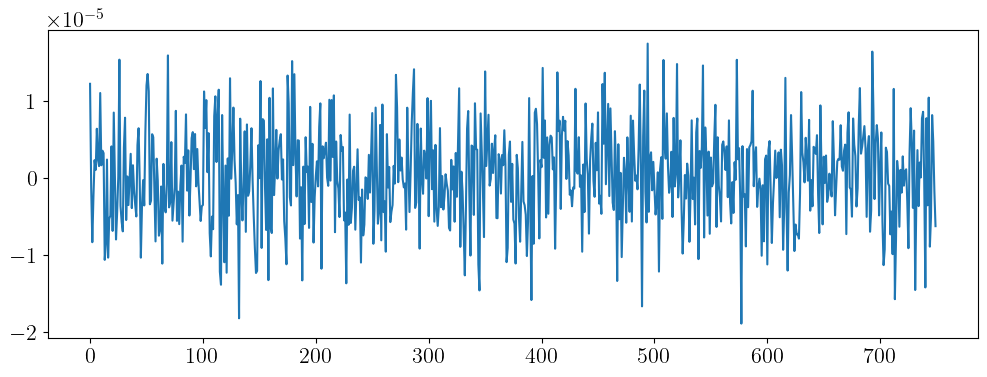

In [258]:
plt.plot(proj_ch4)

In [259]:
H_est_CF_proj_CO2, h_est_CF_proj_CO2, freq_CF_proj_CO2 = utils_TF.identify_system(co2_conc, proj_co2, freq_s, nperseg)
H_est_CF_proj_ch4, h_est_CF_proj_ch4, freq_CF_proj_ch4 = utils_TF.identify_system(ch4_conc, proj_ch4, freq_s, nperseg)

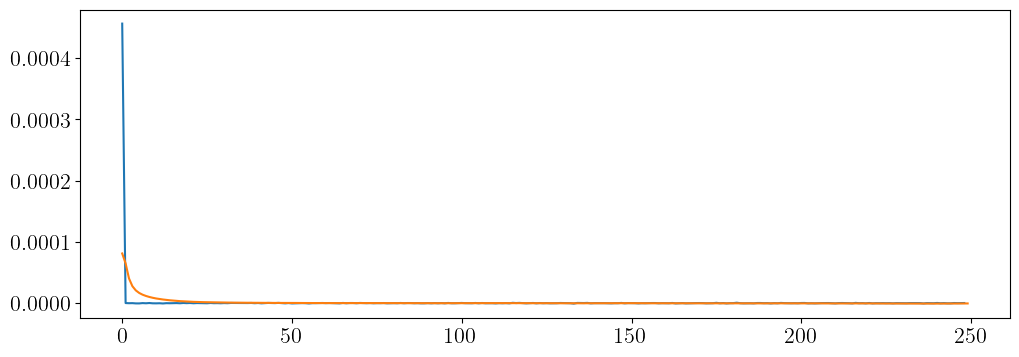

In [263]:
plt.plot(h_est_CF_proj_ch4[:-1])
plt.plot(response_dict['CH4']['h_est_CT'])